In [1]:
import pandas as pd
import tensorflow as tf
import tensorflow.keras as K
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
pd.set_option('display.max_columns', None)

In [8]:
df = pd.read_csv("dataset1.csv",index_col=0,parse_dates=True)
def CreateWindow(X,Y,window=5):
    dataX,dataY = [],[]
    for i in range(len(X)-window-1):
        dataX.append(X[i:i+window])
        dataY.append(Y[i+window])
    return np.array(dataX),np.array(dataY)


In [6]:
df.columns

Index(['financial', 'news', 'sentiment_roberta_neg', 'sentiment_roberta_pos',
       'sentiment_roberta_neut', 'sentiment_distilRoberta_neg',
       'sentiment_distilRoberta_neut', 'sentiment_generic_neg',
       'sentiment_generic_pos', 'sentiment_generic_neut',
       'sentiment_finbert_tone_neg', 'sentiment_finbert_tone_neut',
       'sentiment_finbert_neg', 'sentiment_finbert_neut', 'tweets_vol',
       'close', 'btc_vol', 'nextClose', 'nextClose_change'],
      dtype='object')

In [9]:
df.drop("nextClose_change",axis=1,inplace=True)
df.dropna(axis=0,inplace=True)


Splitting Train dataframe and Test dataframe

In [10]:
train_df = df[:"2022-06-01"]
test_df = df["2022-06-01":]

In [11]:
len(test_df)

213

In [7]:
# scaler = MinMaxScaler(feature_range=(0,1))
# train_scaled = scaler.fit_transform(train_df.values)
# test_scaled = scaler.transform(test_df.values)

In [12]:
def TrainNormalizer(dataframe):
    dataframe = dataframe.copy()
    sentiments_features = dataframe.iloc[:,:-3].values
    tweet_vol = dataframe.iloc[:,-3].values.reshape(-1,1)
    price_close = dataframe.iloc[:,-2].values.reshape(-1,1)
    btc_vol = dataframe.iloc[:,-1].values.reshape(-1,1)
    sentiments_scaler = MinMaxScaler(feature_range=(0,1))
    sentiments_features = sentiments_scaler.fit_transform(sentiments_features)

    tweets_vol_scaler = MinMaxScaler(feature_range=(0,1))
    price_scaler = MinMaxScaler(feature_range=(0,1))
    btc_vol_scaler = MinMaxScaler(feature_range=(0,1))
    tweet_vol = tweets_vol_scaler.fit_transform(tweet_vol)
    price_close = price_scaler.fit_transform(price_close)
    btc_vol = btc_vol_scaler.fit_transform(btc_vol)

    features = np.hstack([sentiments_features,tweet_vol,price_close,btc_vol])

    return features,price_close,sentiments_scaler,tweets_vol_scaler,price_scaler,btc_vol_scaler


def TestNormalizer(dataframe,sentiments_scaler,tweets_vol_scaler,price_scaler,btc_vol_scaler):
    dataframe = dataframe.copy()
    sentiments_features = dataframe.iloc[:,:-3].values
    tweet_vol = dataframe.iloc[:,-3].values.reshape(-1,1)
    price_close = dataframe.iloc[:,-2].values.reshape(-1,1)
    btc_vol = dataframe.iloc[:,-1].values.reshape(-1,1)

    sentiments_features = sentiments_scaler.transform(sentiments_features)
    tweet_vol =tweets_vol_scaler.transform(tweet_vol)
    price_close = price_scaler.transform(price_close)
    btc_vol = btc_vol_scaler.transform(btc_vol)

    features = np.hstack([sentiments_features,tweet_vol,price_close,btc_vol])
    return features,price_close


    

In [13]:
features,price_close,sentiments_scaler,tweets_vol_scaler,price_scaler,btc_vol_scaler = TrainNormalizer(train_df)

In [55]:
features_test,price_close_test = TestNormalizer(test_df,sentiments_scaler,tweets_vol_scaler,price_scaler,btc_vol_scaler)

In [146]:
lags = 20

trainX,trainY = CreateWindow(features,price_close,window=lags)
testX,testY = CreateWindow(features_test,price_close_test,window=lags)

In [132]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    tf.keras.callbacks.TensorBoard(log_dir='./logs'),
]


model = K.models.Sequential()
model.add(K.layers.Bidirectional(K.layers.LSTM(12, return_sequences=True,input_shape=(trainX.shape[1], trainX.shape[2]))))
model.add(K.layers.Bidirectional(K.layers.LSTM(8, return_sequences=False,input_shape=(trainX.shape[1], trainX.shape[2]))))
#model.add(K.layers.LayerNormalization())
#model.add(K.layers.Dropout(0.50))
#model.add(K.layers.LSTM(8, return_sequences=False,input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(K.layers.Dense(1))
model.compile(loss='mse', optimizer='adam',metrics=["mse","mae"])
history = model.fit(trainX, trainY, epochs=200, batch_size=4, validation_split=0.1, verbose=1,callbacks=my_callbacks, shuffle=False)
model.evaluate(testX,testY)

Epoch 1/200
360/360 [==============================] - 40s 79ms/step - loss: 0.0050 - mse: 0.0050 - mae: 0.0488 - val_loss: 0.0379 - val_mse: 0.0379 - val_mae: 0.1847
Epoch 2/200
360/360 [==============================] - 26s 72ms/step - loss: 0.0084 - mse: 0.0084 - mae: 0.0539 - val_loss: 0.0745 - val_mse: 0.0745 - val_mae: 0.2646
Epoch 3/200
360/360 [==============================] - 25s 69ms/step - loss: 0.0185 - mse: 0.0185 - mae: 0.0806 - val_loss: 0.0833 - val_mse: 0.0833 - val_mae: 0.2809
Epoch 4/200
360/360 [==============================] - 25s 69ms/step - loss: 0.0257 - mse: 0.0257 - mae: 0.0929 - val_loss: 0.0418 - val_mse: 0.0418 - val_mae: 0.1919
Epoch 5/200
360/360 [==============================] - 24s 66ms/step - loss: 0.0270 - mse: 0.0270 - mae: 0.0960 - val_loss: 0.0361 - val_mse: 0.0361 - val_mae: 0.1799
Epoch 6/200
360/360 [==============================] - 25s 69ms/step - loss: 0.0190 - mse: 0.0190 - mae: 0.0813 - val_loss: 0.0292 - val_mse: 0.0292 - val_mae: 0.165

[0.021479936316609383, 0.021479936316609383, 0.14177775382995605]

In [ ]:
[0.018429499119520187, 0.018429499119520187, 0.12839408218860626] #8
[0.0069031245075166225, 0.0069031245075166225, 0.07285090535879135] #12
[0.01149324793368578, 0.01149324793368578, 0.09792942553758621] #16
[0.021479936316609383, 0.021479936316609383, 0.14177775382995605] #12,8

7/7 [==============================] - 0s 23ms/step - loss: 0.0289


0.02893100492656231

In [179]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    tf.keras.callbacks.TensorBoard(log_dir='./logs'),
]


model = K.models.Sequential()
model.add(K.layers.SimpleRNN(5, return_sequences=False,input_shape=(trainX.shape[1], trainX.shape[2])))
#model.add(K.layers.Bidirectional(K.layers.LSTM(5, return_sequences=False,input_shape=(trainX.shape[1], trainX.shape[2]))))
#model.add(K.layers.LayerNormalization())
# model.add(K.layers.TimeDistributed(
#     K.layers.Dense(4, activation='relu')
# ))
#model.add(K.layers.Flatten())
#model.add(K.layers.LSTM(5, return_sequences=False,input_shape=(trainX.shape[1], trainX.shape[2])))
#model.add(K.layers.Dropout(0.50))
#model.add(K.layers.LSTM(8, return_sequences=False,input_shape=(trainX.shape[1], trainX.shape[2])))
#model.add(K.layers.Dense(12,activation="relu"))
model.add(K.layers.Dense(1))
model.compile(loss='mse', optimizer='adam',metrics=["mse","mae"])
history = model.fit(trainX, trainY, epochs=500, batch_size=32, validation_split=0.1, verbose=1,callbacks=my_callbacks, shuffle=False)
model.evaluate(testX,testY)

Epoch 1/500
45/45 [==============================] - 14s 248ms/step - loss: 1.1731 - mse: 1.4716 - mae: 1.1731 - val_loss: 0.7733 - val_mse: 0.6916 - val_mae: 0.7733
Epoch 2/500
45/45 [==============================] - 6s 126ms/step - loss: 0.3753 - mse: 0.2206 - mae: 0.3753 - val_loss: 0.2842 - val_mse: 0.1118 - val_mae: 0.2842
Epoch 3/500
45/45 [==============================] - 6s 129ms/step - loss: 0.3265 - mse: 0.1545 - mae: 0.3265 - val_loss: 0.1753 - val_mse: 0.0468 - val_mae: 0.1753
Epoch 4/500
45/45 [==============================] - 6s 136ms/step - loss: 0.2970 - mse: 0.1279 - mae: 0.2970 - val_loss: 0.1449 - val_mse: 0.0320 - val_mae: 0.1449
Epoch 5/500
45/45 [==============================] - 6s 136ms/step - loss: 0.2492 - mse: 0.0913 - mae: 0.2492 - val_loss: 0.1131 - val_mse: 0.0204 - val_mae: 0.1131
Epoch 6/500
45/45 [==============================] - 6s 123ms/step - loss: 0.2263 - mse: 0.0768 - mae: 0.2263 - val_loss: 0.1005 - val_mse: 0.0160 - val_mae: 0.1005
Epoch 7/5

[0.06127536669373512, 0.004223691299557686, 0.06127536669373512]

In [180]:
pred = model.predict(testX)
pred.shape

7/7 [==============================] - 1s 116ms/step


(193, 1)

7/7 [==============================] - 1s 56ms/step
0.004223691046735777
0.06127536295538626
17462372.859134056
3939.956703367876


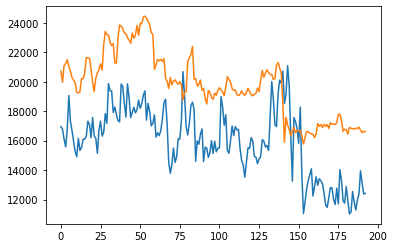

In [204]:
pred = model.predict(testX)


pred_inversed = price_scaler.inverse_transform(pred)
testY_inversed = price_scaler.inverse_transform(testY)
print(mean_squared_error(pred_inversed,testY_inversed))
print(mean_absolute_error(pred_inversed,testY_inversed))
plt.plot(pred_inversed)
plt.plot(testY_inversed)

In [14]:
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA

In [15]:
lags = 1

trainX,trainY = CreateWindow(features,price_close,window=lags)
testX,testY = CreateWindow(features_test,price_close_test,window=lags)

trainX = trainX.reshape(len(trainX),trainX.shape[1]*trainX.shape[2])
testX = testX.reshape(len(testX),testX.shape[1]*testX.shape[2])
# print(trainX.shape)
# pca = PCA(n_components=85,random_state=43)
# trainX = pca.fit_transform(trainX)
# testX = pca.transform(testX)
# print(trainX.shape)

NameError: name 'features_test' is not defined

0.0004179327476106413
0.015940047280708292
1727896.1265392755
1024.932387787441


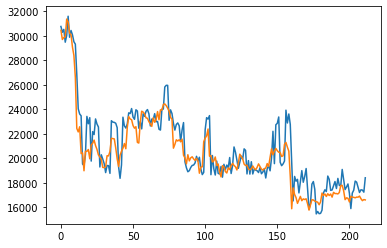

In [282]:
#rf =RandomForestRegressor(n_jobs=-1,n_estimators=500)
#rf = AdaBoostRegressor(n_estimators=100)
rf =XGBRegressor(n_jobs=-1,n_estimators=100)
rf.fit(trainX,trainY)
pred = rf.predict(testX)
print(mean_squared_error(pred,testY))
print(mean_absolute_error(pred,testY))
pred_inversed = price_scaler.inverse_transform(pred.reshape(-1,1))
testY_inversed = price_scaler.inverse_transform(testY)
print(mean_squared_error(pred_inversed,testY_inversed))
print(mean_absolute_error(pred_inversed,testY_inversed))
plt.plot(pred_inversed)
plt.plot(testY_inversed)

In [ ]:
L20
0.0021941883991572586
0.03952339574148859
9071624.25773347
2541.322727461123
RF(500)
----
RF(1000)
9596695.625050865
2600.3667430051355
--
RF(100)
0.0019217947217113368
0.036874338342600746
7780615.569685235
2336.837341968917
----
Ada
0.0020815153656226493
0.0337356945057551
8605790.319044543
2169.178168164448
---
xgb
0.00203302156582771
0.03431513480672651
8405299.308110215
2206.4358949967614

In [ ]:
L10
xgb
0.0014472371785643424
0.028781775494090896
5983439.656458649
1850.6453067272166
--
ada
0.001486653508166479
0.0267499115621755
6146401.117017764
1719.9979135186343
--
rf(100)
0.0012646410482286977
0.027129517642337408
5228515.662029396
1744.4062807881808
--
rf(500)
0.0012197323504497242
0.025994121968712224
5042845.720327294
1671.4012472906206
--
rf(1000)
0.0011128388572312145
0.025348897429761274
4600906.638684468
1629.9138256157057



In [ ]:
L5
rf(1000)
0.0006531031743037778
0.018498021695986515
2700181.35229064
1189.407996634576
rf(500)
0.0006379034018311987
0.018119912231830296
2637339.60874335
1165.0958605769024
rf(100)
0.0006533248538594936
0.018619404927995332
2701097.8613907006
1197.2128413461576
ada(50)
0.0004906426887884946
0.014756489207791514
2028506.8133633328
948.8304508696287
xgb(100)
0.0007827649268100147
0.019795007300077223
3236253.8504720833
1272.8032883864182

L1
ada50
0.0003918173867252219
0.013235652868094647
1619924.7573195794
851.041890896192
ada500
0.0003456485389147312
0.012221890345931137
1429044.8675570989
785.8577717310953
ada100
0.00036133863779971734
0.012213821146758
1493913.8103087533
785.3389286796221
rf100
0.0003566268194151892
0.013240924664809984
1474433.3290649652
851.38086320755
rf500
0.0003594843245981326
0.013367109661506832
1486247.3616904886
859.4944575471601
xgb100
0.0004179327476106413
0.015940047280708292
1727896.1265392755
1024.932387787441




In [291]:
trainX.shape

(1592, 340)

In [295]:
model = K.models.Sequential()
model.add(K.layers.Dense(32,input_shape=(trainX.shape[1],),activation="relu"))
#model.add(K.layers.LayerNormalization())
model.add(K.layers.Dropout(0.5))
model.add(K.layers.Dense(32,activation="relu"))
model.add(K.layers.Dropout(0.5))
#model.add(K.layers.LayerNormalization())
model.add(K.layers.Dense(8,activation="relu"))
#model.add(K.layers.LayerNormalization())
#model.add(K.layers.Dropout(0.5))
model.add(K.layers.Dense(1))
model.compile(loss='mse', optimizer='adam',metrics=["mse","mae"])
history = model.fit(trainX, trainY, epochs=500, batch_size=4, validation_split=0.1, verbose=1,callbacks=my_callbacks, shuffle=False)
model.evaluate(testX,testY)

Epoch 1/500
358/358 [==============================] - 5s 10ms/step - loss: 0.0084 - mse: 0.0084 - mae: 0.0635 - val_loss: 0.1521 - val_mse: 0.1521 - val_mae: 0.3785
Epoch 2/500
358/358 [==============================] - 2s 7ms/step - loss: 0.0172 - mse: 0.0172 - mae: 0.0763 - val_loss: 0.0679 - val_mse: 0.0679 - val_mae: 0.2449
Epoch 3/500
358/358 [==============================] - 3s 7ms/step - loss: 0.0228 - mse: 0.0228 - mae: 0.0844 - val_loss: 0.0718 - val_mse: 0.0718 - val_mae: 0.2571
Epoch 4/500
358/358 [==============================] - 2s 7ms/step - loss: 0.0372 - mse: 0.0372 - mae: 0.1268 - val_loss: 0.0112 - val_mse: 0.0112 - val_mae: 0.0817
Epoch 5/500
358/358 [==============================] - 2s 7ms/step - loss: 0.0759 - mse: 0.0759 - mae: 0.2013 - val_loss: 0.0121 - val_mse: 0.0121 - val_mae: 0.0973
Epoch 6/500
358/358 [==============================] - 2s 7ms/step - loss: 0.0805 - mse: 0.0805 - mae: 0.2217 - val_loss: 0.0279 - val_mse: 0.0279 - val_mae: 0.1493
Epoch 7/5

[0.015037632547318935, 0.015037632547318935, 0.11761056631803513]

7/7 [==============================] - 0s 20ms/step
0.06178857155198203
0.2456113455124172
255457887.73546138
15792.613441143134


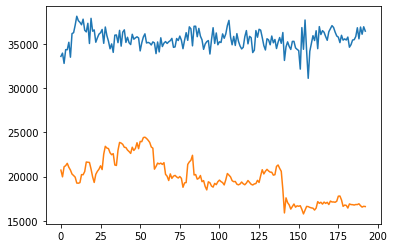

In [293]:
pred = model.predict(testX)
print(mean_squared_error(pred,testY))
print(mean_absolute_error(pred,testY))
pred_inversed = price_scaler.inverse_transform(pred.reshape(-1,1))
testY_inversed = price_scaler.inverse_transform(testY)
print(mean_squared_error(pred_inversed,testY_inversed))
print(mean_absolute_error(pred_inversed,testY_inversed))
plt.plot(pred_inversed)
plt.plot(testY_inversed)